<a href="https://colab.research.google.com/github/AnanyaUp/ANN-Deep-Learning/blob/main/Node_classification_using_GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
version = torch.__version__
i = version.find('+')
version = version[:i-1] + '0' + version[i:]
url = 'https://data.pyg.org/whl/torch-' + version + '.html'

!pip install torch-scatter -f $url
!pip install torch-sparse -f $url
!pip install torch-geometric
!pip install torch-cluster -f $url
!pip install pygod
!pip install --upgrade scipy

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 83.7 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 65.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.8 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.6 MB/s eta 0:00:00


In [ ]:
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
import torch_geometric.transforms as T

import matplotlib.pyplot as plt
import networkx as nx
import random
import numpy as np
from collections import Counter

import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import MessagePassing
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.utils import add_self_loops, degree
from torch_geometric.nn import GCNConv

In [ ]:
dataset = Planetoid(root="data/Planetoid", name="Cora", transform=NormalizeFeatures())
data = dataset[0]

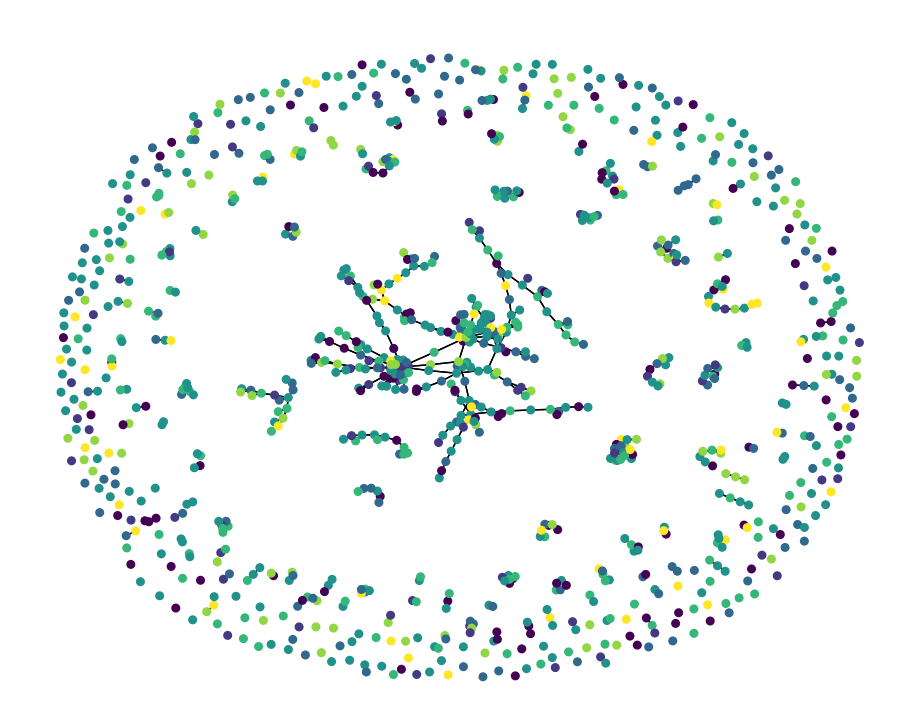

In [ ]:
def convert_to_networkx(graph, n_sample=None):

    g = to_networkx(graph, node_attrs=["x"])
    y = graph.y.cpu().numpy()

    if n_sample is not None:
        sampled_nodes = random.sample(list(g.nodes), n_sample)
        g = g.subgraph(sampled_nodes)
        y = y[sampled_nodes]

    return g, y


def plot_graph(g, y):

    plt.figure(figsize=(9, 7))
    nx.draw_spring(g, node_size=30, arrows=False, node_color=y)
    plt.show()


g, y = convert_to_networkx(data, n_sample=1000)
plot_graph(g, y)

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_node_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        output = self.conv2(x, edge_index)

        return output

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Training
def train(model, data, optimizer, criterion, n_epochs=200):

    for epoch in range(1, n_epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        pred = out.argmax(dim=1)
        acc = evaluate(model, data, data.val_mask)

        if epoch % 10 == 0:
            print(f'Epoch: {epoch:03d}, Train Loss: {loss:.3f}, Val Accuracy: {acc:.3f}')

    return model

In [ ]:
def evaluate(model, data, mask):

    model.eval()
    pred = model(data).argmax(dim=1)
    correct = (pred[mask] == data.y[mask]).sum()
    acc = int(correct) / int(mask.sum())

    return acc

In [ ]:
gcn = GCN().to(device)
optimizer_gcn = torch.optim.Adam(gcn.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()
gcn = train(gcn, data, optimizer_gcn, criterion)

test_acc = evaluate(gcn, data, data.test_mask)
print(f'Test Accuracy: {test_acc:.3f}')

Epoch: 010, Train Loss: 1.846, Val Accuracy: 0.368
Epoch: 020, Train Loss: 1.668, Val Accuracy: 0.704
Epoch: 030, Train Loss: 1.437, Val Accuracy: 0.744
Epoch: 040, Train Loss: 1.173, Val Accuracy: 0.764
Epoch: 050, Train Loss: 0.926, Val Accuracy: 0.770
Epoch: 060, Train Loss: 0.731, Val Accuracy: 0.780
Epoch: 070, Train Loss: 0.594, Val Accuracy: 0.788
Epoch: 080, Train Loss: 0.500, Val Accuracy: 0.788
Epoch: 090, Train Loss: 0.434, Val Accuracy: 0.786
Epoch: 100, Train Loss: 0.386, Val Accuracy: 0.788
Epoch: 110, Train Loss: 0.349, Val Accuracy: 0.784
Epoch: 120, Train Loss: 0.319, Val Accuracy: 0.788
Epoch: 130, Train Loss: 0.296, Val Accuracy: 0.786
Epoch: 140, Train Loss: 0.276, Val Accuracy: 0.786
Epoch: 150, Train Loss: 0.259, Val Accuracy: 0.788
Epoch: 160, Train Loss: 0.245, Val Accuracy: 0.792
Epoch: 170, Train Loss: 0.233, Val Accuracy: 0.792
Epoch: 180, Train Loss: 0.223, Val Accuracy: 0.790
Epoch: 190, Train Loss: 0.214, Val Accuracy: 0.792
Epoch: 200, Train Loss: 0.206, 